# Modelo de Regresión Lineal para la predicción de TCH y Sacarosa

Este cuaderno desarrolla un modelo base de **regresión lineal múltiple** para predecir dos variables continuas de interés en el cultivo de caña de azúcar: **TCH** (Toneladas de Caña por Hectárea) y **%Sac.Caña**.

A diferencia de los modelos de clasificación, en este enfoque no se agrupan los valores en categorías como bajo, medio o alto. En cambio, se busca estimar directamente el valor numérico de cada variable objetivo a partir de variables agronómicas, climáticas y de manejo seleccionadas durante el EDA.

El objetivo principal es construir un modelo interpretable que funcione como línea base para comparar posteriormente con modelos más flexibles o no lineales.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

## 2. Carga de datasets procesados

Se cargan únicamente los archivos finales de **regresión** generados en el EDA. No se usan los archivos de clasificación, ya que esos contienen variables objetivo discretizadas en clases y pertenecen a otro enfoque de modelado.

In [2]:
REG_TCH_PATH = '../data/processed/datos_limpios_regresion_tch.csv'
REG_SAC_PATH = '../data/processed/datos_limpios_regresion_sacarosa.csv'

data_tch = pd.read_csv(REG_TCH_PATH)
data_sac = pd.read_csv(REG_SAC_PATH)

print("Shape dataset TCH:", data_tch.shape)
print("Shape dataset Sacarosa:", data_sac.shape)

display(data_tch.head())
display(data_sac.head())

Shape dataset TCH: (20733, 19)
Shape dataset Sacarosa: (20578, 19)


,Area Neta,Dist Km,Variedad,Edad Ult Cos,Cultivo,Dosis Madurante,Semanas mad.,TCH,Vejez,Tipo Quema,T.Corte,M3 Riego,DDUlt.Riego,Lluvias (2 Meses Ant.),Lluvias 0 -3,Lluvias tres a seis,Lluvias seis a nueve,Luvias 9 -FC,%Infest.Diatrea
0,6.00,4.3,34,12.81,0,1.0,8.428571,121.198333,2.735,3,1,0.0,0,258.0,0.0,454.0,102.0,482.0,0.0
1,1.45,21.9,34,11.14,0,0.0,8.571428,93.793103,73.823,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,8.24,23.0,4,12.32,0,1.1,8.428571,174.347087,2.108,3,1,48513.6,107,246.0,106.0,326.0,113.0,457.0,0.0
3,1.05,66.5,6,9.79,0,0.0,8.571428,136.790476,64.614,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.53,17.0,51,11.53,0,0.0,8.571428,113.068432,71.021,1,0,0.0,0,138.0,264.0,255.0,188.0,284.0,0.0


,Area Neta,Dist Km,Variedad,Edad Ult Cos,Cultivo,Dosis Madurante,Semanas mad.,%Sac.Caña,Vejez,Tipo Quema,T.Corte,M3 Riego,DDUlt.Riego,Lluvias (2 Meses Ant.),Lluvias 0 -3,Lluvias tres a seis,Lluvias seis a nueve,Luvias 9 -FC,%Infest.Diatrea
0,6.00,4.3,34,12.81,0,1.0,8.428571,13.7582,2.735,4,1,0.0,0,258.0,0.0,454.0,102.0,482.0,0.0
1,1.45,21.9,34,11.14,0,0.0,8.571428,12.8430,73.823,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,8.24,23.0,4,12.32,0,1.1,8.428571,11.9364,2.108,4,1,48513.6,107,246.0,106.0,326.0,113.0,457.0,0.0
3,1.05,66.5,6,9.79,0,0.0,8.571428,11.2770,64.614,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.53,17.0,51,11.53,0,0.0,8.571428,10.2160,71.021,1,0,0.0,0,138.0,264.0,255.0,188.0,284.0,0.0


El dataset de TCH conserva `TCH` como variable objetivo y elimina `%Sac.Caña`, mientras que el dataset de sacarosa conserva `%Sac.Caña` como variable objetivo y elimina `TCH`. Esta separación evita fuga de información entre variables resultado.

## 3. Revisión de variables disponibles

In [3]:
print("Columnas para regresión TCH:")
print(data_tch.columns.tolist())

print("Columnas para regresión Sacarosa:")
print(data_sac.columns.tolist())

Columnas para regresión TCH:
['Area Neta', 'Dist Km', 'Variedad', 'Edad Ult Cos', 'Cultivo', 'Dosis Madurante', 'Semanas mad.', 'TCH', 'Vejez', 'Tipo Quema', 'T.Corte', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea']
Columnas para regresión Sacarosa:
['Area Neta', 'Dist Km', 'Variedad', 'Edad Ult Cos', 'Cultivo', 'Dosis Madurante', 'Semanas mad.', '%Sac.Caña', 'Vejez', 'Tipo Quema', 'T.Corte', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea']


Durante el EDA se seleccionaron variables relacionadas con área, distancia, edad del cultivo, variedad, cultivo, maduración, riego, lluvias, tipo de corte, tipo de quema y presencia de plaga. Estas variables representan factores agronómicos y de manejo que pueden influir tanto en el rendimiento (`TCH`) como en la concentración de sacarosa (`%Sac.Caña`).

Aunque las variables categóricas fueron codificadas previamente en el EDA, en este notebook se tratan nuevamente como categóricas mediante `OneHotEncoder` para evitar que la regresión lineal interprete sus códigos numéricos como valores con orden o distancia real.

## 4. Funciones auxiliares para entrenamiento y evaluación

Se define una función general para entrenar y evaluar el modelo de regresión lineal. Esta función permite repetir el mismo flujo para TCH y sacarosa, manteniendo consistencia en la comparación.

Las métricas utilizadas son:

- **MAE**: error absoluto medio. Indica cuánto se equivoca el modelo en promedio.
- **MSE**: error cuadrático medio. Penaliza con mayor fuerza errores grandes.
- **RMSE**: raíz del MSE. Tiene la misma unidad de la variable objetivo.
- **R²**: proporción de variabilidad explicada por el modelo.

In [4]:
def evaluar_regresion(y_true, y_pred, nombre_objetivo):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados para {nombre_objetivo} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    
    return {
        "Objetivo": nombre_objetivo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def construir_pipeline(X, categorical_cols):
    categorical_cols = [col for col in categorical_cols if col in X.columns]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])
    
    return pipeline, numeric_cols, categorical_cols


def graficar_reales_vs_predichos(y_true, y_pred, titulo):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Valores reales")
    plt.ylabel("Valores predichos")
    plt.title(titulo)
    plt.grid(True)
    plt.show()


def graficar_residuos(y_true, y_pred, titulo):
    residuos = y_true - y_pred
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuos, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Valores predichos")
    plt.ylabel("Residuos")
    plt.title(titulo)
    plt.grid(True)
    plt.show()


def obtener_coeficientes(modelo):
    preprocessor = modelo.named_steps["preprocessor"]
    regressor = modelo.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    
    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coeficiente": regressor.coef_
    })
    
    coef_df["Importancia_abs"] = coef_df["Coeficiente"].abs()
    coef_df = coef_df.sort_values("Importancia_abs", ascending=False)
    
    return coef_df

## 5. Modelo de regresión lineal para TCH

### 5.1. Definición de características y variable objetivo

Para el primer modelo se utiliza `TCH` como variable objetivo. Las demás columnas disponibles en el dataset de regresión se usan como variables predictoras.

In [5]:
target_tch = "TCH"

X_tch = data_tch.drop(columns=[target_tch])
y_tch = data_tch[target_tch]

categorical_cols = ["Variedad", "Cultivo", "Tipo Quema", "T.Corte"]

X_train_tch, X_test_tch, y_train_tch, y_test_tch = train_test_split(
    X_tch,
    y_tch,
    test_size=0.2,
    random_state=42
)

print("Tamaño entrenamiento:", X_train_tch.shape)
print("Tamaño prueba:", X_test_tch.shape)

Tamaño entrenamiento: (16586, 18)
Tamaño prueba: (4147, 18)


El conjunto de prueba se reserva desde el inicio para evaluar la capacidad de generalización del modelo. Como se trata de regresión, no se usa `stratify`, ya que la variable objetivo es continua.

### 5.2. Creación del pipeline

El pipeline integra el preprocesamiento y el modelo. Las variables numéricas se imputan con la mediana y se escalan. Las variables categóricas se imputan con la moda y se codifican.

In [6]:
pipe_tch, num_tch, cat_tch = construir_pipeline(X_tch, categorical_cols)

print("Variables numéricas:", num_tch)
print("Variables categóricas:", cat_tch)

Variables numéricas: ['Area Neta', 'Dist Km', 'Edad Ult Cos', 'Dosis Madurante', 'Semanas mad.', 'Vejez', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea']
Variables categóricas: ['Variedad', 'Cultivo', 'Tipo Quema', 'T.Corte']


Este enfoque evita fuga de información porque las transformaciones se ajustan únicamente con el conjunto de entrenamiento y luego se aplican al conjunto de prueba.

### 5.3. Validación cruzada en entrenamiento

Antes de evaluar en prueba, se calcula el R² promedio mediante validación cruzada sobre el conjunto de entrenamiento.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_tch = cross_val_score(
    pipe_tch,
    X_train_tch,
    y_train_tch,
    cv=cv,
    scoring="r2"
)

print("R² por fold:", cv_scores_tch)
print("R² promedio CV:", cv_scores_tch.mean())
print("Desviación estándar CV:", cv_scores_tch.std())

R² por fold: [0.20516827 0.22542153 0.20982321 0.21830607 0.21692443]
R² promedio CV: 0.2151287028975334
Desviación estándar CV: 0.007023119798519437


La validación cruzada permite observar qué tan estable es el comportamiento del modelo en diferentes particiones del conjunto de entrenamiento. Un R² bajo o muy variable indicaría que la relación lineal entre las variables predictoras y TCH es limitada o poco estable.La validación cruzada permite observar qué tan estable es el comportamiento del modelo en diferentes particiones del conjunto de entrenamiento. Un R² bajo o muy variable indicaría que la relación lineal entre las variables predictoras y TCH es limitada o poco estable.

De los resultados se puede deducir que el modelo de regresión logística presenta un **comportamiento bastante estable entre las particiones**, porque los valores de R² por fold son muy similares entre sí y la desviación estándar es baja, aproximadamente **0.007**. Esto indica que el modelo no cambia mucho dependiendo de cómo se divida el conjunto de entrenamiento, por lo que no parece haber una alta inestabilidad en la validación cruzada. Sin embargo, el **R² promedio de 0.215** es bajo, lo que sugiere que las variables predictoras explican solo una parte limitada de la variabilidad asociada a TCH.


### 5.4. Entrenamiento y evaluación en prueba

In [8]:
pipe_tch.fit(X_train_tch, y_train_tch)

y_pred_tch = pipe_tch.predict(X_test_tch)

resultados_tch = evaluar_regresion(y_test_tch, y_pred_tch, "TCH")

--- Resultados para TCH ---
MAE  : 21.8439
MSE  : 851.0250
RMSE : 29.1723
R²   : 0.1913


El MAE y el RMSE indican el error promedio del modelo en unidades de TCH. Por su parte, el R² permite medir qué proporción de la variabilidad del rendimiento logra explicar la regresión lineal. Si el R² es bajo, significa que el modelo lineal solo captura parcialmente el comportamiento del TCH.

De estos resultados se puede deducir que el modelo de regresión lineal tiene una capacidad predictiva limitada para estimar el TCH. El **MAE de 21.84** indica que, en promedio, las predicciones del modelo se alejan aproximadamente **21.84 unidades de TCH** respecto a los valores reales. Además, el **RMSE de 29.17**, al ser mayor que el MAE, sugiere que existen errores más grandes en algunas predicciones, posiblemente casos donde el modelo se equivoca considerablemente. Por otra parte, el **R² de 0.1913** significa que el modelo solo logra explicar cerca del **19.13% de la variabilidad del TCH**, lo cual es bajo. Entonces, aunque el modelo puede captar una parte del comportamiento del rendimiento, la mayor parte de la variación no está siendo explicada por las variables utilizadas, por lo que sería necesario incluir mejores predictores, transformar variables o probar modelos más complejos para mejorar el desempeño.


### 5.5. Visualización de predicciones y residuos para TCH

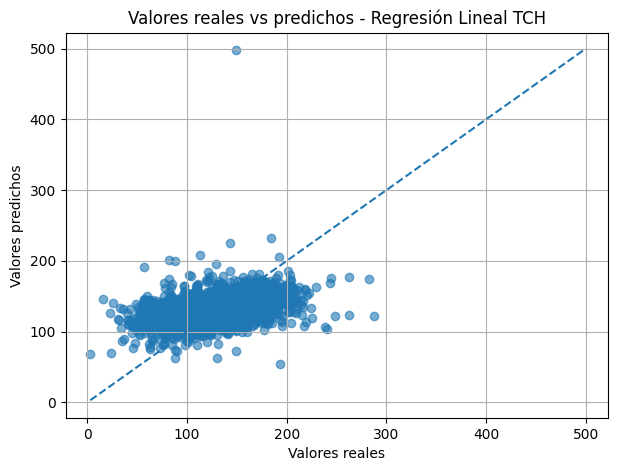

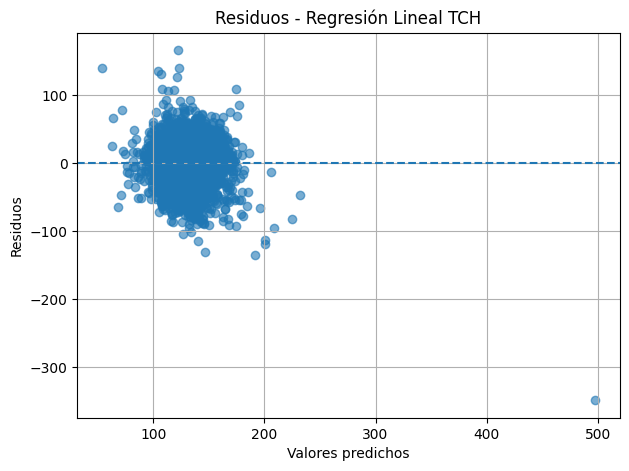

In [9]:
graficar_reales_vs_predichos(
    y_test_tch,
    y_pred_tch,
    "Valores reales vs predichos - Regresión Lineal TCH"
)

graficar_residuos(
    y_test_tch,
    y_pred_tch,
    "Residuos - Regresión Lineal TCH"
)

En la gráfica de valores reales contra predichos, un modelo ideal tendría los puntos cercanos a la línea diagonal. Si los puntos aparecen muy dispersos, el modelo presenta dificultades para estimar correctamente el TCH.

La gráfica de residuos permite revisar si los errores se distribuyen de forma aleatoria alrededor de cero. Patrones claros, curvaturas o dispersión desigual pueden indicar que existen relaciones no lineales que la regresión lineal no logra capturar.

### 5.6. Análisis de coeficientes para TCH

La regresión lineal permite interpretar la influencia de las variables mediante sus coeficientes. Debido al escalamiento de variables numéricas, los coeficientes pueden compararse de forma más estable.

In [10]:
coef_tch = obtener_coeficientes(pipe_tch)
coef_tch.head(15)

,Variable,Coeficiente,Importancia_abs
19,cat__Variedad_5,78.617490,78.617490
57,cat__Variedad_44,57.794611,57.794611
61,cat__Variedad_49,-56.871474,56.871474
32,cat__Variedad_19,27.522427,27.522427
48,cat__Variedad_35,-26.308333,26.308333
31,cat__Variedad_18,26.091207,26.091207
14,cat__Variedad_0,-23.140970,23.140970
62,cat__Variedad_50,-22.635366,22.635366
37,cat__Variedad_24,-21.463071,21.463071
29,cat__Variedad_16,18.652362,18.652362


Las variables con coeficientes de mayor magnitud son las que tienen mayor influencia dentro del modelo lineal. Un coeficiente positivo indica que, manteniendo las demás variables constantes, el aumento de esa característica se asocia con un incremento del TCH. Un coeficiente negativo indica una relación inversa.


## 6. Modelo de regresión lineal para Sacarosa

### 6.1. Definición de características y variable objetivo

Para el segundo modelo se utiliza `%Sac.Caña` como variable objetivo. Este dataset fue construido en el EDA eliminando `TCH`, de manera que se evita usar una variable resultado para predecir otra.

In [11]:
target_sac = "%Sac.Caña"

X_sac = data_sac.drop(columns=[target_sac])
y_sac = data_sac[target_sac]

X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(
    X_sac,
    y_sac,
    test_size=0.2,
    random_state=42
)

print("Tamaño entrenamiento:", X_train_sac.shape)
print("Tamaño prueba:", X_test_sac.shape)

Tamaño entrenamiento: (16462, 18)
Tamaño prueba: (4116, 18)


### 6.2. Creación del pipeline para sacarosa

In [12]:
pipe_sac, num_sac, cat_sac = construir_pipeline(X_sac, categorical_cols)

print("Variables numéricas:", num_sac)
print("Variables categóricas:", cat_sac)

Variables numéricas: ['Area Neta', 'Dist Km', 'Edad Ult Cos', 'Dosis Madurante', 'Semanas mad.', 'Vejez', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea']
Variables categóricas: ['Variedad', 'Cultivo', 'Tipo Quema', 'T.Corte']


Se mantiene la misma estructura de preprocesamiento y modelado utilizada para TCH. Esto permite comparar ambos objetivos bajo condiciones similares.

### 6.3. Validación cruzada en entrenamiento

In [13]:
cv_scores_sac = cross_val_score(
    pipe_sac,
    X_train_sac,
    y_train_sac,
    cv=cv,
    scoring="r2"
)

print("R² por fold:", cv_scores_sac)
print("R² promedio CV:", cv_scores_sac.mean())
print("Desviación estándar CV:", cv_scores_sac.std())

R² por fold: [0.26594295 0.29067363 0.266191   0.26956283 0.24513459]
R² promedio CV: 0.26750100070634575
Desviación estándar CV: 0.014461134581268301


La validación cruzada permite verificar si el comportamiento del modelo para sacarosa es consistente o si depende demasiado de una partición específica de los datos.

De estos resultados se puede deducir que el modelo para **sacarosa** tiene un comportamiento **relativamente consistente en la validación cruzada**, ya que los valores de R² por fold son cercanos entre sí y la desviación estándar es baja, aproximadamente **0.0145**. Esto indica que el desempeño del modelo no depende demasiado de una partición específica de los datos, sino que mantiene una estabilidad aceptable entre los diferentes subconjuntos de entrenamiento y prueba. Sin embargo, el **R² promedio de 0.2675** sigue siendo bajo, lo que significa que el modelo solo logra explicar cerca del **26.75% de la variabilidad de la sacarosa**. Por tanto, aunque el modelo es estable, su capacidad explicativa es limitada; es decir, las variables utilizadas sí aportan cierta información, pero no son suficientes para representar completamente el comportamiento de la sacarosa.


### 6.4. Entrenamiento y evaluación en prueba

In [14]:
pipe_sac.fit(X_train_sac, y_train_sac)

y_pred_sac = pipe_sac.predict(X_test_sac)

resultados_sac = evaluar_regresion(y_test_sac, y_pred_sac, "Sacarosa")

--- Resultados para Sacarosa ---
MAE  : 0.7657
MSE  : 0.9746
RMSE : 0.9872
R²   : 0.2667


En este caso, el MAE y el RMSE se interpretan en unidades de porcentaje de sacarosa. Un error bajo indicaría que el modelo logra aproximarse adecuadamente al contenido real de sacarosa, mientras que un R² bajo sugeriría que las variables disponibles no explican completamente su variabilidad mediante una relación lineal.

De estos resultados se puede deducir que el modelo para sacarosa logra hacer predicciones con un error relativamente bajo en términos absolutos, ya que el **MAE de 0.7657** indica que, en promedio, las predicciones se alejan aproximadamente **0.77 puntos porcentuales** del valor real de sacarosa. El **RMSE de 0.9872** muestra que, aunque el error promedio no es muy alto, existen algunos casos donde las diferencias entre el valor real y el predicho son mayores. Sin embargo, el **R² de 0.2667** indica que el modelo solo explica cerca del **26.67% de la variabilidad de la sacarosa**, lo cual sigue siendo bajo. Por lo tanto, aunque el modelo puede aproximarse razonablemente a los valores reales en términos de error, su capacidad para explicar el comportamiento general de la sacarosa mediante una relación lineal es limitada; es decir, las variables usadas no capturan completamente los factores que influyen en el contenido de sacarosa.


### 6.5. Visualización de predicciones y residuos para Sacarosa

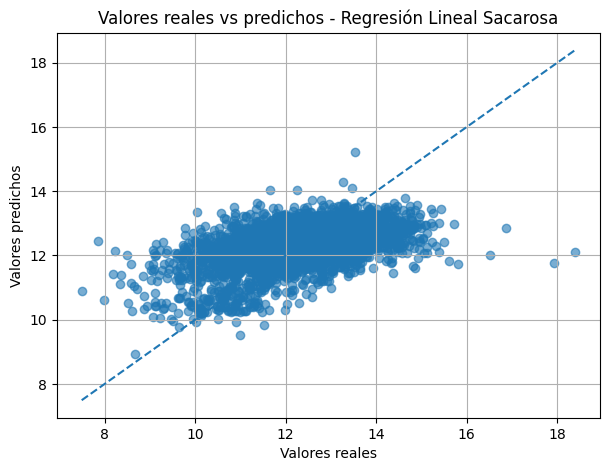

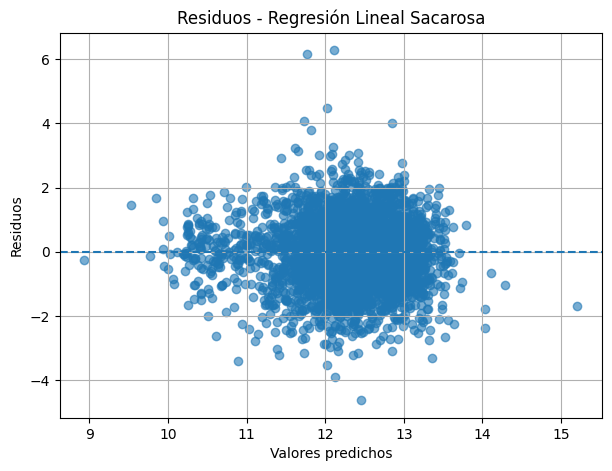

In [15]:
graficar_reales_vs_predichos(
    y_test_sac,
    y_pred_sac,
    "Valores reales vs predichos - Regresión Lineal Sacarosa"
)

graficar_residuos(
    y_test_sac,
    y_pred_sac,
    "Residuos - Regresión Lineal Sacarosa"
)

Estas gráficas permiten evaluar visualmente si la regresión lineal logra aproximar los valores reales de sacarosa. Si los residuos muestran patrones sistemáticos o alta dispersión, esto puede ser evidencia de relaciones no lineales o de variables faltantes importantes.

### 6.6. Análisis de coeficientes para Sacarosa

In [16]:
coef_sac = obtener_coeficientes(pipe_sac)
coef_sac.head(15)

,Variable,Coeficiente,Importancia_abs
30,cat__Variedad_17,3.615054,3.615054
16,cat__Variedad_3,1.840074,1.840074
34,cat__Variedad_21,-1.501336,1.501336
56,cat__Variedad_43,-1.433694,1.433694
23,cat__Variedad_10,1.398821,1.398821
39,cat__Variedad_26,-1.202966,1.202966
66,cat__Variedad_53,-1.117926,1.117926
65,cat__Variedad_52,-1.097682,1.097682
37,cat__Variedad_24,1.010780,1.010780
58,cat__Variedad_45,-1.007282,1.007282


Los coeficientes permiten identificar qué variables se asocian más fuertemente con el contenido de sacarosa. Variables relacionadas con maduración, lluvias, edad del cultivo y manejo agronómico pueden aparecer como relevantes, lo cual sería coherente con el comportamiento fisiológico de la caña de azúcar.

## 7. Comparación general de resultados

In [17]:
resumen_resultados = pd.DataFrame([resultados_tch, resultados_sac])
resumen_resultados

,Objetivo,MAE,MSE,RMSE,R2
0,TCH,21.843945,851.025022,29.172333,0.191337
1,Sacarosa,0.765747,0.974617,0.987227,0.266695


La comparación de métricas permite identificar cuál variable objetivo es más fácil de estimar mediante una relación lineal.

- Si TCH presenta menor RMSE relativo y mayor R², significa que el rendimiento agrícola está mejor explicado por las variables seleccionadas.
- Si sacarosa obtiene mejores resultados, podría indicar que los factores de maduración y manejo incluidos en el dataset explican mejor la variabilidad de la calidad de la caña.
- Si ambos R² son bajos, esto sugiere que la regresión lineal funciona principalmente como modelo base, pero no captura toda la complejidad del problema.

## 8. Conclusiones

La regresión lineal permitió construir un modelo base para la predicción continua de TCH y sacarosa a partir de variables agronómicas y de manejo. La estrategia de validación, basada en una partición hold-out 80/20 y validación cruzada de 5 pliegues sobre el conjunto de entrenamiento, permitió evaluar la estabilidad del modelo y su capacidad de generalización.

En el caso de TCH, el modelo mostró un desempeño bajo, con un R² de 0.1913, lo que indica que solo logra explicar una proporción limitada de la variabilidad del rendimiento. Los errores obtenidos (MAE de 21.84 y RMSE de 29.17) evidencian desviaciones considerables entre los valores reales y predichos. Esto sugiere que el comportamiento de TCH no puede ser adecuadamente representado mediante una relación lineal simple entre las variables.

Para sacarosa, el modelo obtuvo un desempeño ligeramente superior, con un R² de 0.2667, lo que indica una mayor capacidad explicativa en comparación con TCH. Los errores fueron menores (MAE de 0.7657 y RMSE de 0.9872), lo que sugiere que la regresión lineal logra capturar parcialmente la tendencia general de la variable, aunque sigue presentando limitaciones importantes.

El análisis de los valores reales vs predichos y de los residuos evidencia que el modelo tiende a concentrar las predicciones en rangos medios, mostrando dificultades para capturar valores extremos. Además, la dispersión de los residuos sugiere la presencia de patrones no lineales y posibles interacciones entre variables que no están siendo modeladas.

Las variables incluidas en el modelo, tales como edad del cultivo, semanas de maduración, riego, lluvias, variedad, tipo de cultivo y presencia de plagas, son coherentes con el conocimiento agronómico. Sin embargo, su efecto sobre TCH y sacarosa parece involucrar relaciones más complejas que no pueden ser capturadas completamente por un modelo lineal.

En conjunto, los resultados muestran que la regresión lineal es útil como modelo base e interpretable, pero su desempeño limitado sugiere que la estructura del problema requiere modelos más flexibles capaces de capturar relaciones no lineales, como Random Forest, Gradient Boosting o XGBoost, los cuales han demostrado un mejor desempeño en este contexto.